<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 5</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Mohammad Reza Pirhadi <br>
        <b>🆔 Student ID:</b> 810102423 <br><br>
        <h5 style="color: #1a365d;"> TASK 4 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 5 - Task 4. It focuses on segmenting football players from broadcast images using unsupervised methods. The implementation covers spatial-color feature extraction, pixel clustering using K-Means and DBSCAN, mathematical post-processing via connected components, and leveraging pre-trained CNN deep feature maps to refine player boundaries without manual annotations.
</div>

## Table of Contents
1. [Image Downscaling & Spatial-Color Feature Extraction](#preprocessing)
2. [Unsupervised Pixel Clustering (K-Means, DBSCAN & Agglomerative)](#clustering)
3. [Cluster Evaluation (Silhouette Score & Inertia Curves)](#hyperparameters)
4. [Domain-Specific Post-Processing (Filtering, Merging & Centroids)](#post-processing)
5. [Deep Feature Extraction via Pre-trained CNNs (ResNet/HRNet Bonus)](#deep-features)
6. [Ground-Truth Evaluation (Dice Coefficient & IoU)](#evaluation)

<a id="preprocessing"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Image Downscaling & Spatial-Color Feature Extraction</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    To manage high memory consumption, high-resolution football broadcast images are downscaled to $1/8$ or $1/16$ of their original size using <code>OpenCV</code>. We extract raw pixel vectors containing color information (RGB/HSV) and append spatial coordinates $(x, y)$ to preserve spatial boundaries during clustering.
</div>


<a id="clustering"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Unsupervised Pixel Clustering (K-Means, DBSCAN & Agglomerative)</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    Pixels are clustered using three unsupervised models: <code>K-Means</code>, <code>DBSCAN</code>, and <code>Agglomerative Clustering</code>. This partition groups visually and spatially similar pixels together to separate foreground structures (players) from the background.
</div>


<a id="hyperparameters"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Cluster Evaluation (Silhouette Score & Inertia Curves)</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    We evaluate the quality of the clusters by calculating <code>Silhouette Scores</code> on sampled subsets and plotting elbow curves (Inertia vs. $K$) for K-Means. This step optimizes hyperparameter selection, such as the number of clusters $K$ and DBSCAN's distance threshold $\epsilon$.
</div>


<a id="post-processing"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4&5. Domain-Specific Post-Processing (Filtering, Merging & Centroids)</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    We filter out large background clusters (such as the green field) and merge small, fragmented clusters. The resulting binary mask is analyzed using <code>Connected Components</code> to isolate individual players, calculate their geometric centroids, and draw bounding boxes around them.
</div>


<a id="deep-features"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">6. Deep Feature Extraction via Pre-trained CNNs (ResNet/HRNet Bonus)</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    We replace raw color values with deep feature maps extracted from the intermediate layers of a pre-trained network (e.g., <code>ResNet</code>). These feature maps are upsampled to match the target image dimensions, providing richer semantic contexts to the clustering models.
</div>


<a id="evaluation"></a>
<h2 style="color: #5490d9; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">7. Ground-Truth Evaluation (Dice Coefficient & IoU)</h2>

<div class="alert alert-warning" style="background-color: #fbf9e7; border-left: 4px solid #ddd420; color: #166111;">
    <strong>⚽ Methodology:</strong>
    We evaluate the segmentation quality by converting the final clustering results into binary masks (players=1, background=0) and comparing them against the expert-annotated ground-truth masks extracted from the provided JSON file[cite: 527, 528]. The spatial overlap is rigorously measured across a 50-image sample using two standard metrics: the Dice Coefficient and Intersection over Union (IoU) [cite: 530, 531], utilizing the strict penalty formula $IoU=\frac{|A\cap B|}{|A\cup B|}$[cite: 540, 542].
</div>

In [ ]:
import os
import json
import random
import warnings
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import local_binary_pattern
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN

warnings.filterwarnings('ignore')

Loading annotations from ./data/instances_default.json...
Processing 50 images with scale factor 0.25...
 Dataset successfully loaded and optimized!

✅ Successfully locked onto image: 64.jpg


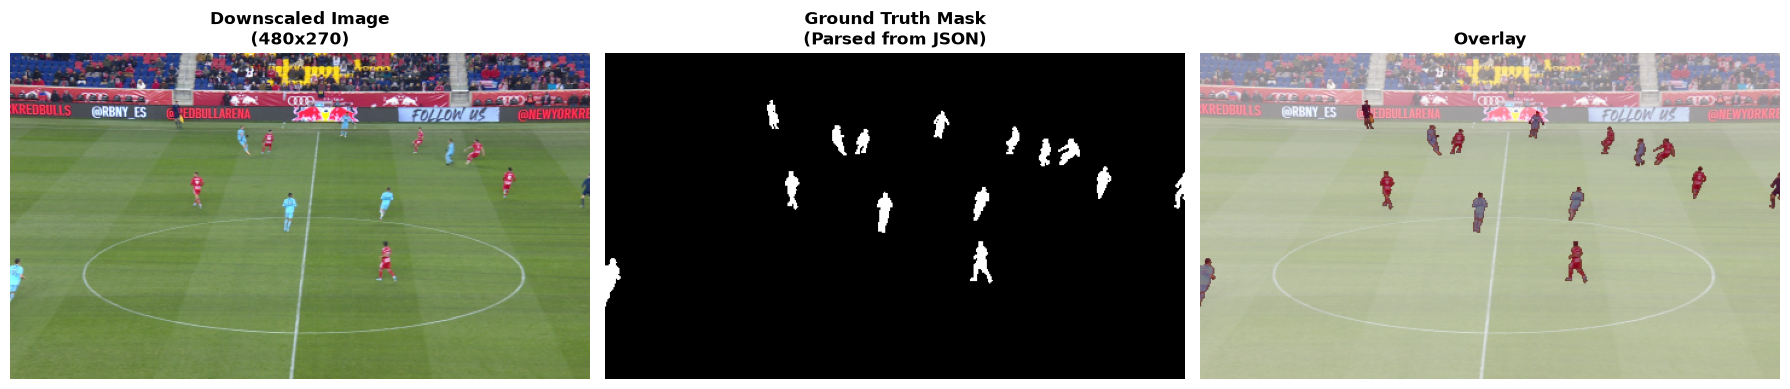

In [ ]:
# ==============================================================================
# SECTION 1: DATASET LOADING, DOWNSCALING & NATIVE COCO MASK GENERATION
# ==============================================================================

class FootballDatasetLoader:
    def __init__(self, images_dir, json_path, scale_factor=0.125, num_samples=50):
        """
        Initializes the loader with paths and parameters.
        scale_factor: 0.125 (1/8) or 0.0625 (1/16) as requested by the document.
        """
        self.images_dir = images_dir
        self.json_path = json_path
        self.scale_factor = scale_factor
        self.num_samples = num_samples
        self.dataset = []

    def _parse_coco_json(self):
        """Loads and indexes the COCO JSON file for fast O(1) lookups."""
        print(f"Loading annotations from {self.json_path}...")
        with open(self.json_path, 'r') as f:
            coco_data = json.load(f)
            
        # Map filename to image_id
        self.filename_to_id = {img['file_name']: img['id'] for img in coco_data.get('images', [])}
        
        # Group annotations by image_id
        self.annotations_by_image = {}
        for ann in coco_data.get('annotations', []):
            img_id = ann['image_id']
            if img_id not in self.annotations_by_image:
                self.annotations_by_image[img_id] = []
            self.annotations_by_image[img_id].append(ann)

    def _generate_mask_for_image(self, image_filename, target_shape):
        """
        Natively parses COCO polygons and draws them directly onto a downscaled mask.
        Eliminates the need for the heavy 'pycocotools' library.
        """
        h, w = target_shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)
        
        img_id = self.filename_to_id.get(image_filename)
        if img_id is None or img_id not in self.annotations_by_image:
            return mask # Return empty mask if no players found

        for ann in self.annotations_by_image[img_id]:
            # category_id == 1 is typically the 'player' or primary object class
            if ann.get('category_id') == 1 and 'segmentation' in ann:
                segmentations = ann['segmentation']
                if isinstance(segmentations, list):
                    for poly in segmentations:
                        # Convert flat list [x1,y1, x2,y2,...] to 2D array
                        poly_array = np.array(poly, dtype=np.float32).reshape((-1, 2))
                        
                        # Downscale coordinates immediately
                        scaled_poly = (poly_array * self.scale_factor).astype(np.int32)
                        scaled_poly = scaled_poly.reshape((-1, 1, 2))
                        
                        # Draw filled polygon (1 = player)
                        cv2.fillPoly(mask, [scaled_poly], 1)
                        
        return mask

    def build_dataset(self):
        """
        Executes the optimized loading pipeline.
        Reads images, downscales on the fly (saves RAM), and builds masks.
        """
        self._parse_coco_json()
        
        all_image_paths = glob(os.path.join(self.images_dir, "*.jpg")) + \
                          glob(os.path.join(self.images_dir, "*.png"))
                          
        if not all_image_paths:
            raise FileNotFoundError(f"No images found in {self.images_dir}")

        # Sample images randomly
        sampled_paths = random.sample(all_image_paths, min(self.num_samples, len(all_image_paths)))
        print(f"Processing {len(sampled_paths)} images with scale factor {self.scale_factor}...")

        for path in sampled_paths:
            filename = os.path.basename(path)
            
            # Read image and convert to RGB
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Downscale ON THE FLY (Crucial for preventing RAM crashes)
            orig_h, orig_w = img.shape[:2]
            new_w, new_h = int(orig_w * self.scale_factor), int(orig_h * self.scale_factor)
            resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
            
            # Generate the downscaled ground truth mask natively
            gt_mask = self._generate_mask_for_image(filename, (new_h, new_w))
            
            # Store in the unified dataset list
            self.dataset.append({
                'filename': filename,
                'image': resized_img, # Stored as uint8 [0-255] to save memory
                'gt_mask': gt_mask
            })
            
        print(" Dataset successfully loaded and optimized!")
        return self.dataset

# ==============================================================================
# VISUALIZATION UTILITY
# ==============================================================================

def visualize_sample(sample_dict):
    """Plots the downscaled image alongside its natively parsed binary mask."""
    img = sample_dict['image']
    mask = sample_dict['gt_mask']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img)
    axes[0].set_title(f"Downscaled Image\n({img.shape[1]}x{img.shape[0]})", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Ground Truth Mask\n(Parsed from JSON)", fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img)
    axes[2].imshow(mask, cmap='Reds', alpha=0.5)
    axes[2].set_title("Overlay", fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EXECUTION BLOCK 
# ==============================================================================
if __name__ == "__main__":
    try:
        IMG_DIR = "./data/images"
        ANN_PATH = "./data/instances_default.json"
        
        loader = FootballDatasetLoader(images_dir=IMG_DIR, json_path=ANN_PATH, scale_factor=0.25, num_samples=50)
        processed_dataset = loader.build_dataset()
        
        if processed_dataset:
            target_image = "0.jpg" 
            
            test_sample = next((item for item in processed_dataset if item['filename'] == target_image), None)
            
            if test_sample is None:
                test_sample = processed_dataset[0]
                
            test_image = test_sample['image']
            test_filename = test_sample['filename']
            
            print(f"\n Successfully locked onto image: {test_filename}")
            visualize_sample(test_sample)
            
    except Exception as e:
        print(f"Initialization Error: {e}")

Extracting features using method: LBP...
Success! Final Matrix Shape: (129600, 5)


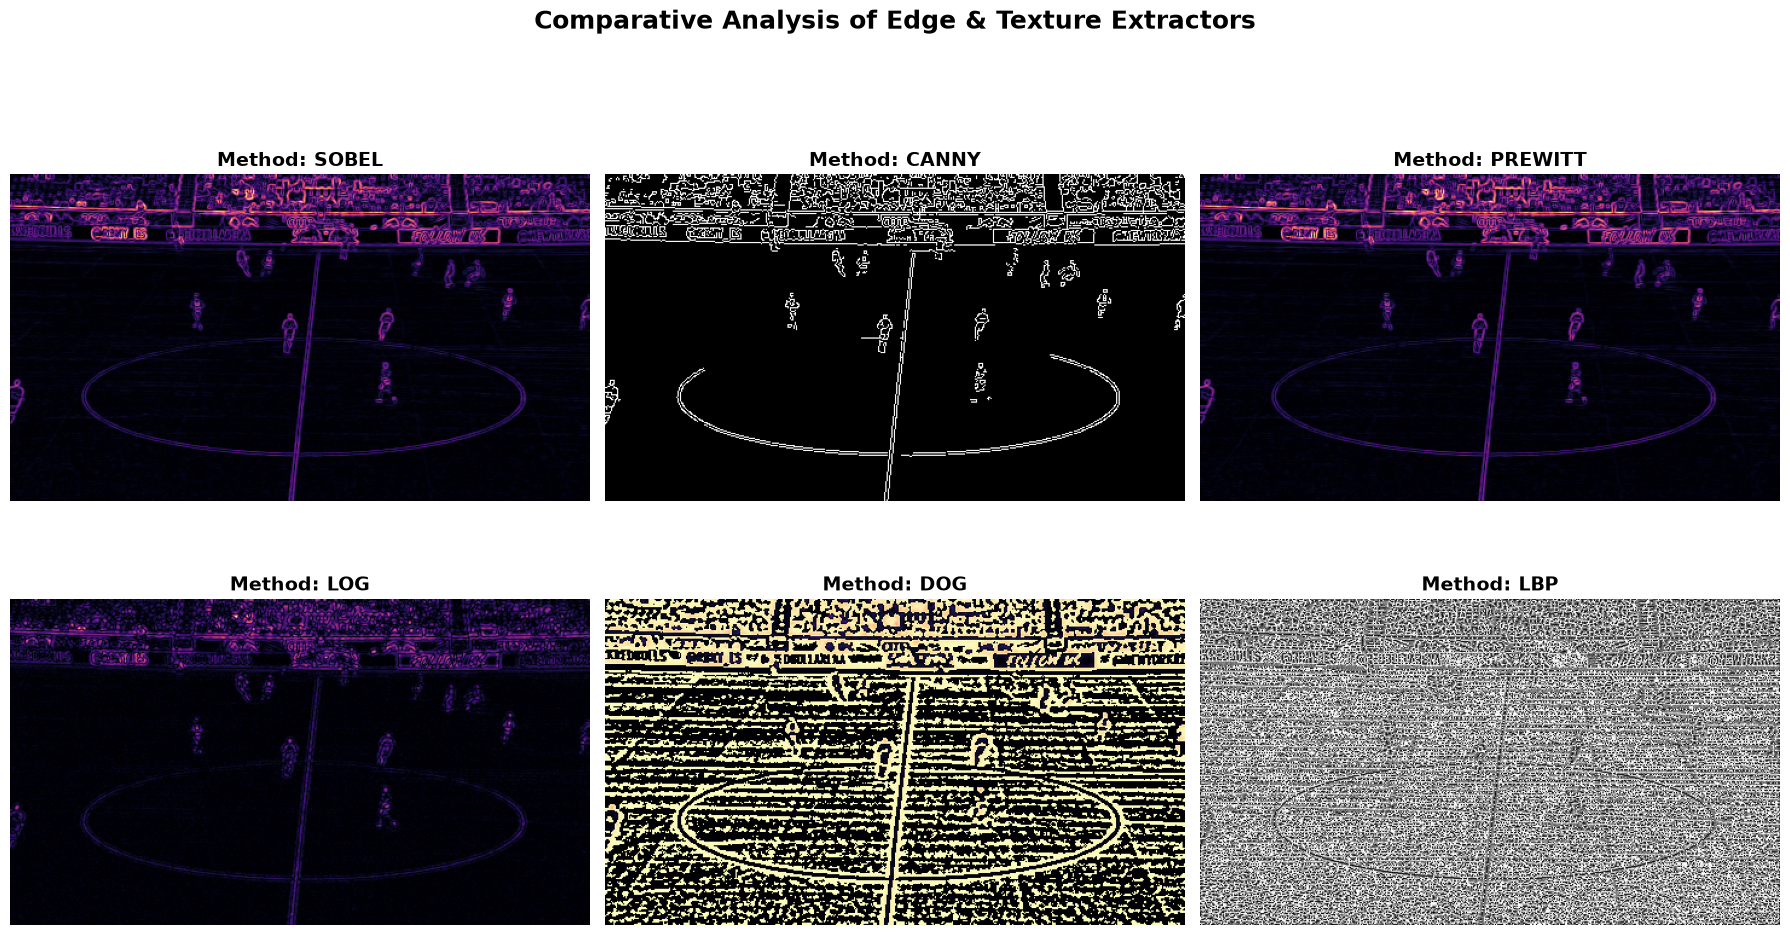

In [43]:
class AdvancedFeatureExtractor:
    def __init__(self, texture_method='sobel', spatial_weight=0.15, texture_weight=0.30):
        self.texture_method = texture_method.lower()
        self.spatial_weight = spatial_weight
        self.texture_weight = texture_weight
        self.scaler = MinMaxScaler()

    def _apply_sobel(self, gray_img):
        grad_x = cv2.Sobel(gray_img, cv2.CV_32F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray_img, cv2.CV_32F, 0, 1, ksize=3)
        return cv2.magnitude(grad_x, grad_y)

    def _apply_canny(self, gray_img):
        img_uint8 = cv2.normalize(gray_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        return cv2.Canny(img_uint8, 100, 200).astype(np.float32)

    def _apply_prewitt(self, gray_img):
        kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
        kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]], dtype=np.float32)
        
        # Enforce CV_32F depth to avoid type assertion error in magnitude function
        grad_x = cv2.filter2D(gray_img, cv2.CV_32F, kernel_x)
        grad_y = cv2.filter2D(gray_img, cv2.CV_32F, kernel_y)
        
        return cv2.magnitude(grad_x, grad_y)

    def _apply_log(self, gray_img):
        blurred = cv2.GaussianBlur(gray_img, (5, 5), 0)
        laplacian = cv2.Laplacian(blurred, cv2.CV_32F)
        return np.abs(laplacian)

    def _apply_dog(self, gray_img):
        blur1 = cv2.GaussianBlur(gray_img, (0, 0), sigmaX=1.0)
        blur2 = cv2.GaussianBlur(gray_img, (0, 0), sigmaX=2.0)
        return np.abs(blur1 - blur2)

    def _apply_lbp(self, gray_img):
        img_uint8 = cv2.normalize(gray_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        lbp = local_binary_pattern(img_uint8, P=8, R=1, method='uniform')
        return lbp.astype(np.float32)

    def extract_features(self, image_rgb):
        h, w = image_rgb.shape[:2]
        
        lab_img = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
        l_chan, a_chan, b_chan = cv2.split(lab_img)
        
        a_norm = a_chan.flatten().astype(np.float32) / 255.0
        b_norm = b_chan.flatten().astype(np.float32) / 255.0

        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        x_norm = xx.flatten().astype(np.float32) / w
        y_norm = yy.flatten().astype(np.float32) / h

        if self.texture_method == 'canny':
            texture_map = self._apply_canny(l_chan)
        elif self.texture_method == 'dog':
            texture_map = self._apply_dog(l_chan)
        elif self.texture_method == 'log':
            texture_map = self._apply_log(l_chan)
        elif self.texture_method == 'sobel':
            texture_map = self._apply_sobel(l_chan)
        elif self.texture_method == 'prewitt':
            texture_map = self._apply_prewitt(l_chan)
        elif self.texture_method == 'lbp':
            texture_map = self._apply_lbp(l_chan)
        else:
            raise ValueError(f"Unknown texture method: {self.texture_method}")

        texture_norm = cv2.normalize(texture_map, None, 0, 1, cv2.NORM_MINMAX).flatten()

        x_weighted = x_norm * self.spatial_weight
        y_weighted = y_norm * self.spatial_weight
        texture_weighted = texture_norm * self.texture_weight

        feature_matrix = np.column_stack((
            a_norm, 
            b_norm, 
            x_weighted, 
            y_weighted, 
            texture_weighted
        ))

        return feature_matrix, (a_chan, b_chan, texture_map)


def compare_all_texture_methods(image_rgb):
    methods = ['sobel', 'canny', 'prewitt', 'log', 'dog', 'lbp']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, method in enumerate(methods):
        extractor = AdvancedFeatureExtractor(texture_method=method, spatial_weight=0.15, texture_weight=0.30)
        _, (_, _, texture_map) = extractor.extract_features(image_rgb)
        
        ax = axes[i]
        cmap = 'gray' if method in ['lbp', 'canny'] else 'magma'
        
        ax.imshow(texture_map, cmap=cmap)
        ax.set_title(f"Method: {method.upper()}", fontsize=14, fontweight='bold')
        ax.axis('off')
        
    plt.suptitle("Comparative Analysis of Edge & Texture Extractors", fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    try:
        test_image = processed_dataset[0]['image']  
        
        CHOSEN_METHOD = 'lbp' 
        
        print(f"Extracting features using method: {CHOSEN_METHOD.upper()}...")
        extractor = AdvancedFeatureExtractor(texture_method=CHOSEN_METHOD, spatial_weight=0.15, texture_weight=0.30)
        
        feature_matrix, (a, b, texture) = extractor.extract_features(test_image)
        print(f"Success! Final Matrix Shape: {feature_matrix.shape}")
        
        compare_all_texture_methods(test_image)

    except NameError:
        print(" Please run Section 1 first to load the 'processed_dataset'.")
    except Exception as e:
        print(f" Error: {e}")

⏳ Running K-Means evaluation (Elbow & Silhouette)...


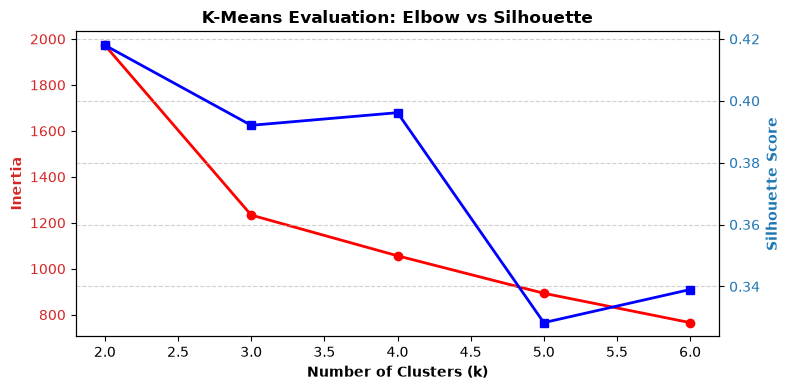


--- Running K-Means (K=3) ---
[K-Means] Silhouette Score: 0.3941

--- Running DBSCAN (eps=0.03, min_samples=30) ---
[DBSCAN] Clusters: 34 | Noise points: 4585
[DBSCAN] Valid Silhouette Score: -0.0848

--- Running HDBSCAN (min_cluster_size=20) ---
[HDBSCAN] Clusters: 100 | Noise points: 15856
[HDBSCAN] Valid Silhouette Score: 0.0596

⏳ Generating Segmentation Maps...


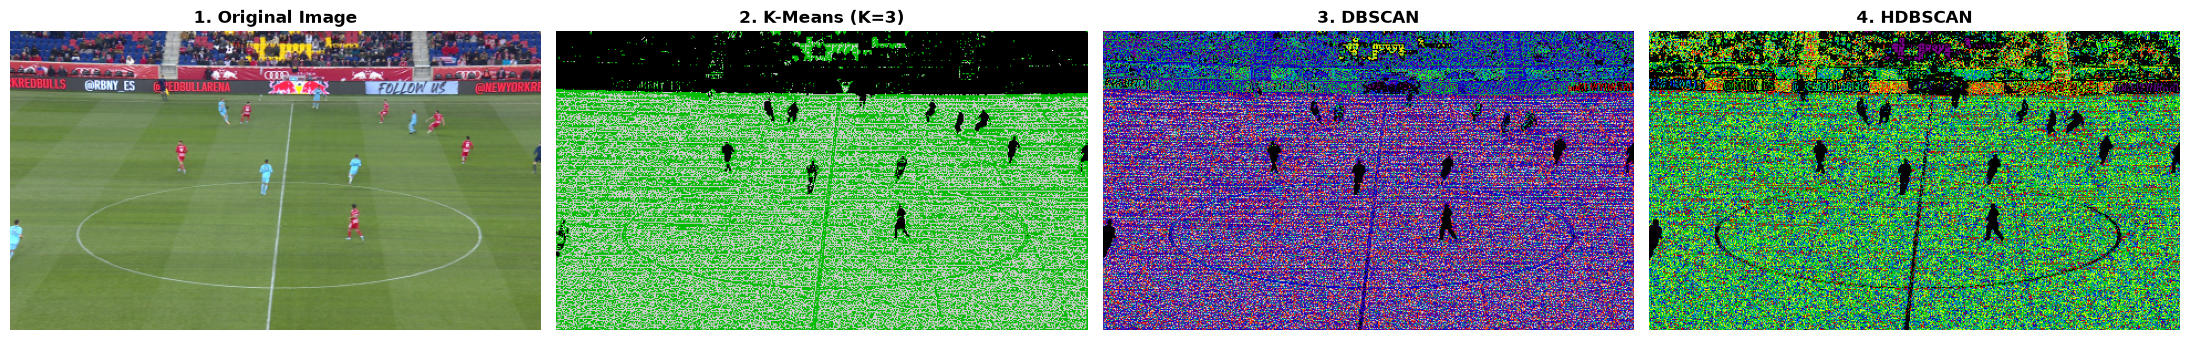

In [ ]:
# ==============================================================================
# SECTION 3: ADVANCED PIXEL CLUSTERING & EVALUATION (IMAGE BY IMAGE)
# ==============================================================================

class PixelClusterer:
    def __init__(self, feature_matrix, image_shape):
        """
        Initializes the clusterer with the highly optimized 5D feature matrix of a SINGLE image.
        """
        self.features = feature_matrix
        self.img_shape = image_shape
        self.h, self.w = image_shape[:2]

    # ---------------------------------------------------------
    # Evaluation Utilities
    # ---------------------------------------------------------
    def _calculate_silhouette(self, labels, sample_size=5000):
        """
        Calculates Silhouette Score using a random sample to prevent memory overflow.
        Ignores noise points (-1) which are natural in DBSCAN/HDBSCAN.
        """
        valid_mask = labels != -1
        valid_features = self.features[valid_mask]
        valid_labels = labels[valid_mask]
        
        if len(np.unique(valid_labels)) > 1:
            score = silhouette_score(
                valid_features, 
                valid_labels, 
                sample_size=sample_size, 
                random_state=42
            )
            return score
        return None

    def plot_kmeans_evaluation(self, max_k=8):
        """
        Plots Inertia (Elbow Method) and Silhouette scores for K-Means to find optimal K.
        """
        print(" Running K-Means evaluation (Elbow & Silhouette)...")
        inertias = []
        sil_scores = []
        k_values = list(range(2, max_k + 1))
        
        subset_idx = np.random.choice(self.features.shape[0], min(5000, len(self.features)), replace=False)
        features_subset = self.features[subset_idx]

        for k in k_values:
            kmeans = KMeans(n_clusters=k, n_init=10, random_state=42).fit(self.features)
            inertias.append(kmeans.inertia_)
            labels_subset = kmeans.predict(features_subset)
            sil_scores.append(silhouette_score(features_subset, labels_subset))

        fig, ax1 = plt.subplots(figsize=(8, 4))
        
        color = 'tab:red'
        ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
        ax1.set_ylabel('Inertia', color=color, fontweight='bold')
        ax1.plot(k_values, inertias, 'ro-', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
        ax2.plot(k_values, sil_scores, 'bs-', linewidth=2)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title("K-Means Evaluation: Elbow vs Silhouette", fontweight='bold')
        fig.tight_layout()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    # ---------------------------------------------------------
    # Clustering Algorithms
    # ---------------------------------------------------------
    def run_kmeans(self, k=3):
        print(f"\n--- Running K-Means (K={k}) ---")
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(self.features)
        
        sil_score = self._calculate_silhouette(labels)
        print(f"[K-Means] Silhouette Score: {sil_score:.4f}" if sil_score else "[K-Means] Invalid for Silhouette")
        
        return labels.reshape((self.h, self.w))

    def run_dbscan(self, eps=0.04, min_samples=50):
        print(f"\n--- Running DBSCAN (eps={eps}, min_samples={min_samples}) ---")
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(self.features)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        sil_score = self._calculate_silhouette(labels)
        
        print(f"[DBSCAN] Clusters: {n_clusters} | Noise points: {n_noise}")
        print(f"[DBSCAN] Valid Silhouette Score: {sil_score:.4f}" if sil_score else "[DBSCAN] Not enough valid clusters")
        
        return labels.reshape((self.h, self.w))

    def run_hdbscan(self, min_cluster_size=20):
        print(f"\n--- Running HDBSCAN (min_cluster_size={min_cluster_size}) ---")
        hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size)
        labels = hdbscan_model.fit_predict(self.features)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        sil_score = self._calculate_silhouette(labels)
        
        print(f"[HDBSCAN] Clusters: {n_clusters} | Noise points: {n_noise}")
        print(f"[HDBSCAN] Valid Silhouette Score: {sil_score:.4f}" if sil_score else "[HDBSCAN] Not enough valid clusters")
        
        return labels.reshape((self.h, self.w))


# ==============================================================================
# EXECUTION & VISUALIZATION BLOCK
# ==============================================================================
if __name__ == "__main__":
    try:
        # Assuming 'test_image' and 'feature_matrix' are already available from Section 1 & 2
        clusterer = PixelClusterer(feature_matrix, test_image.shape)
        
        # 1. Evaluate K-Means mathematically to justify choosing K=3 or K=4
        clusterer.plot_kmeans_evaluation(max_k=6)
        
        # 2. Run all three algorithms with tuned parameters
        # For K-Means: K=3 is usually Background(Grass), Players A, Players B/Ref
        kmeans_map = clusterer.run_kmeans(k=3)
        
        # DBSCAN parameters are highly dependent on the feature scaling. 
        # Since our features are 0-1, eps should be small.
        dbscan_map = clusterer.run_dbscan(eps=0.03, min_samples=30)
        
        # HDBSCAN only needs the minimum size of a valid player mask (e.g., 20 pixels)
        hdbscan_map = clusterer.run_hdbscan(min_cluster_size=20)
        
        # 3. Visualize the comparison
        print("\n Generating Segmentation Maps...")
        fig, axes = plt.subplots(1, 4, figsize=(22, 6))
        
        axes[0].imshow(test_image)
        axes[0].set_title("1. Original Image", fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(kmeans_map, cmap='nipy_spectral')
        axes[1].set_title("2. K-Means (K=3)", fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(dbscan_map, cmap='nipy_spectral')
        axes[2].set_title("3. DBSCAN", fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(hdbscan_map, cmap='nipy_spectral')
        axes[3].set_title("4. HDBSCAN", fontweight='bold')
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

    except NameError:
        print(" Please run Section 2 first to generate the 'feature_matrix'.")
    except Exception as e:
        print(f" Clustering Error: {e}")

1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...


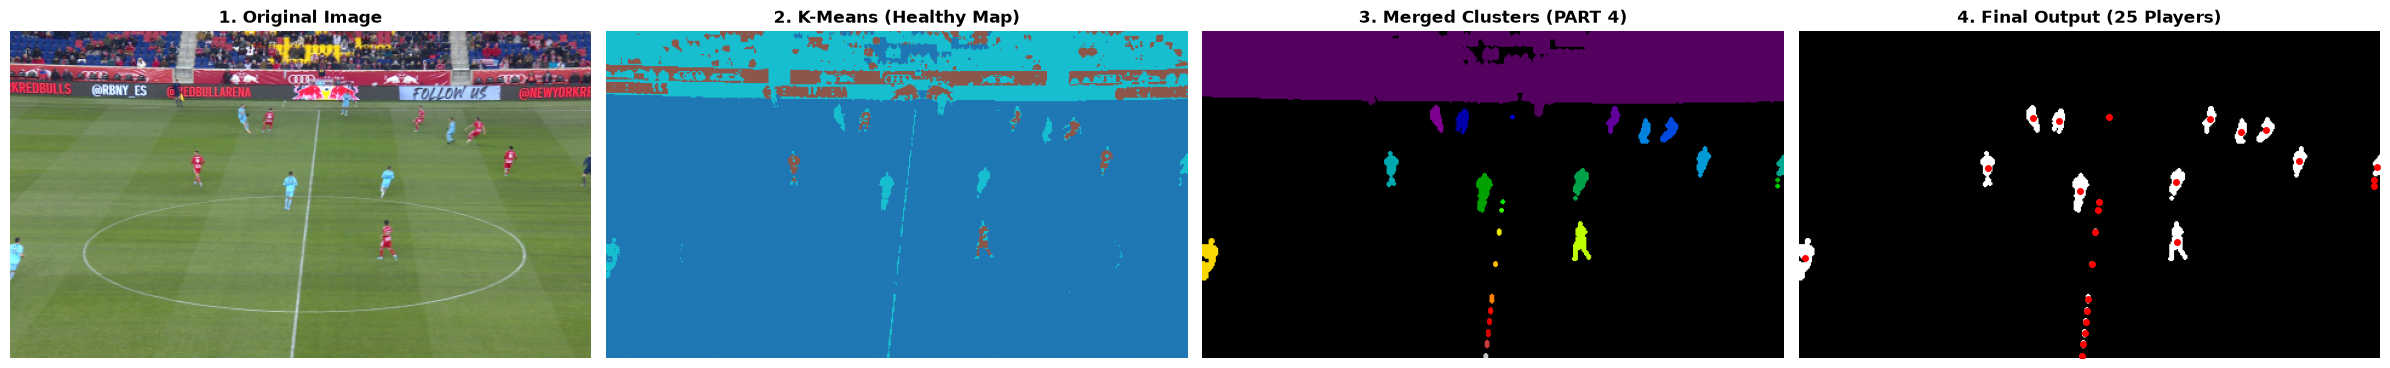

In [ ]:
# ==============================================================================
# ULTIMATE END-TO-END PIPELINE (BYPASSING NOTEBOOK MEMORY ISSUES)
# ==============================================================================

class UnifiedFootballPipeline:
    def __init__(self, spatial_weight=0.1, k_clusters=3):
        self.spatial_weight = spatial_weight
        self.k_clusters = k_clusters
        self.morph_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        
    def _extract_features(self, img_rgb):
        print("1/4  Extracting Color and Spatial Features...")
        h, w = img_rgb.shape[:2]
        
        # Color (LAB)
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        _, a, b = cv2.split(lab)
        a_norm = a.flatten().astype(np.float32) / 255.0
        b_norm = b.flatten().astype(np.float32) / 255.0
        
        # Spatial
        xx, yy = np.meshgrid(np.arange(w), np.arange(h))
        x_norm = (xx.flatten().astype(np.float32) / w) * self.spatial_weight
        y_norm = (yy.flatten().astype(np.float32) / h) * self.spatial_weight
        
        return np.column_stack((a_norm, b_norm, x_norm, y_norm))
        
    def _cluster_pixels(self, features, shape):
        print("2/4  Running K-Means Clustering...")
        h, w = shape[:2]
        kmeans = KMeans(n_clusters=self.k_clusters, random_state=42, n_init=5)
        labels = kmeans.fit_predict(features)
        return labels.reshape((h, w))
        
    def _remove_pitch(self, cluster_map):
        print("3/4  Removing the Pitch...")
        labels, counts = np.unique(cluster_map, return_counts=True)
        grass_label = labels[np.argmax(counts)]
        
        binary_mask = np.ones_like(cluster_map, dtype=np.uint8) * 255
        binary_mask[cluster_map == grass_label] = 0
        return binary_mask
        
    def _find_players(self, binary_mask):
        print("4/4  Morphological Filtering & Extracting Centroids...")
        cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)))
        cleaned = cv2.dilate(cleaned, self.morph_kernel, iterations=1)
        
        num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
        
        final_mask = np.zeros_like(cleaned, dtype=np.uint8)
        valid_centroids = []
        
        for i in range(1, num_labels): 
            w = stats[i, cv2.CC_STAT_WIDTH]
            h = stats[i, cv2.CC_STAT_HEIGHT]
            area = stats[i, cv2.CC_STAT_AREA]
            ratio = h / (w + 1e-5)
            
            # Very loose constraints just to drop obvious lines and noise
            if (3 <= area <= 600) and (0.2 <= ratio <= 5.0):
                final_mask[labels_im == i] = 255
                valid_centroids.append(centroids[i])
                
        return labels_im, final_mask, np.array(valid_centroids)

    def run(self, image):
        features = self._extract_features(image)
        kmap = self._cluster_pixels(features, image.shape)
        binary_fg = self._remove_pitch(kmap)

        merged_clusters, mask, centroids = self._find_players(binary_fg)
        return kmap, merged_clusters, mask, centroids

# ==============================================================================
# EXECUTION
# ==============================================================================
if __name__ == "__main__":
    try:
        # Resolve the image securely
        if 'test_image' in locals() or 'test_image' in globals():
            img = test_image
        # elif 'test_img_norm' in locals() or 'test_img_norm' in globals():
        #     # If your image is 0-1 float, convert back to 0-255 uint8 for processing
        #     img = (test_img_norm[..., :3] * 255).astype(np.uint8) if test_img_norm.max() <= 1.0 else test_img_norm[..., :3]
        else:
            raise ValueError("No image found! Please load an image first.")

        # Initialize and Run
        pipeline = UnifiedFootballPipeline(spatial_weight=0.1)
        cluster_map, merged_clusters, final_mask, player_centroids = pipeline.run(img)
        
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(img)
        axes[0].set_title("1. Original Image", fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(cluster_map, cmap='tab10')
        axes[1].set_title("2. K-Means (Healthy Map)", fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(merged_clusters, cmap='nipy_spectral')
        axes[2].set_title("3. Merged Clusters (PART 4)", fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(final_mask, cmap='gray')
        if len(player_centroids) > 0:
            axes[3].plot(player_centroids[:, 0], player_centroids[:, 1], 'ro', markersize=4)
        axes[3].set_title(f"4. Final Output ({len(player_centroids)} Players)", fontweight='bold')
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Error: {e}")

⚙️ Initializing Deep Fusion Model on: cpu
1/5 ⏳ Extracting and Fusing Features (CNN + RGB)...
2/5 ⏳ Reducing dimensions with PCA (to 6 dims)...
3/5 ⏳ Clustering Fused Features (K-Means)...
4/5 ⏳ Identifying and removing the Pitch...
5/5 ⏳ Morphological Merging & Centroid Extraction...


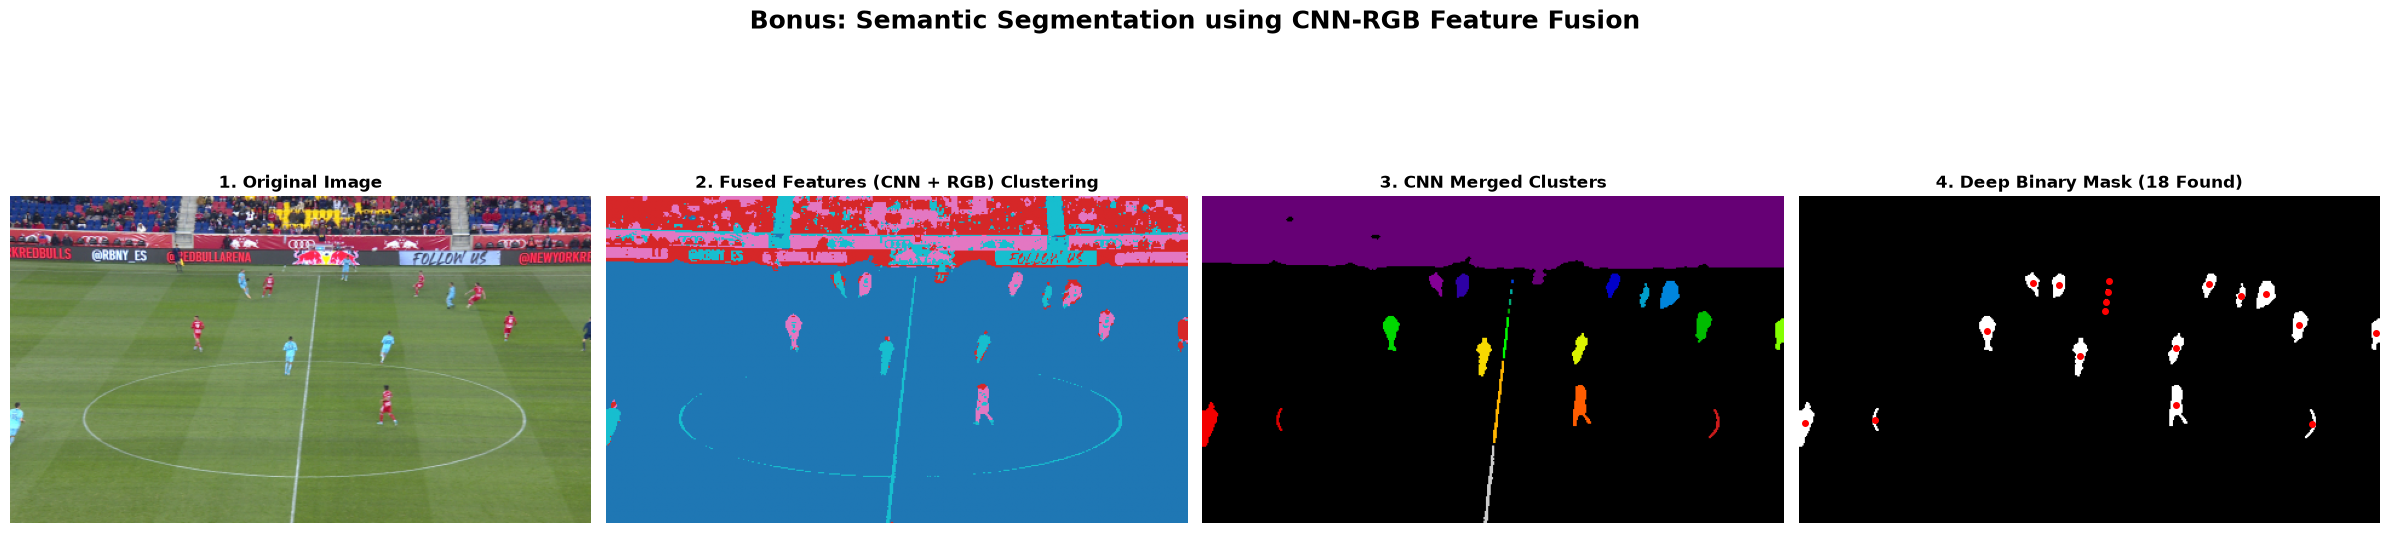

In [ ]:
# ==============================================================================
# BONUS (V2): DEEP FEATURE FUSION (CNN SEMANTICS + RGB CRISPNESS)
# ==============================================================================

class DeepFusionPipeline:
    def __init__(self, n_components=6, k_clusters=4, rgb_weight=2.0, device=None):
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f" Initializing Deep Fusion Model on: {self.device}")
        
        self.model = models.resnet18(pretrained=True).to(self.device)
        self.model.eval()
        
        # 1. Use 'layer1' instead of 'layer2' (Preserves much higher spatial resolution)
        self.intermediate_features = {}
        def get_activation(name):
            def hook(model, input, output):
                self.intermediate_features[name] = output
            return hook
        self.model.layer1.register_forward_hook(get_activation('layer1'))
        
        self.preprocess = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.pca = PCA(n_components=n_components, random_state=42)
        self.k_clusters = k_clusters
        self.rgb_weight = rgb_weight # How strongly to enforce sharp pixel boundaries
        self.morph_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    def _extract_fused_features(self, img_rgb):
        print("1/5  Extracting and Fusing Features (CNN + RGB)...")
        h, w = img_rgb.shape[:2]
        
        # A. Extract Deep Features
        img_tensor = self.preprocess(img_rgb).unsqueeze(0).to(self.device)
        with torch.no_grad():
            _ = self.model(img_tensor)
            
        deep_feat = self.intermediate_features['layer1']
        upsampled_feat = F.interpolate(deep_feat, size=(h, w), mode='bilinear', align_corners=False)
        cnn_2d = upsampled_feat.squeeze(0).permute(1, 2, 0).cpu().numpy()
        cnn_flat = cnn_2d.reshape((h * w, -1))
        
        # B. Normalize CNN Features
        cnn_flat = (cnn_flat - cnn_flat.mean(axis=0)) / (cnn_flat.std(axis=0) + 1e-8)
        
        # C. Extract and Normalize High-Res RGB Features
        rgb_flat = img_rgb.reshape((h * w, 3)).astype(np.float32) / 255.0
        rgb_flat = (rgb_flat - rgb_flat.mean(axis=0)) / (rgb_flat.std(axis=0) + 1e-8)
        
        # D. FUSION (Combine meaning and crisp boundaries)
        fused_features = np.hstack((cnn_flat, rgb_flat * self.rgb_weight))
        
        return fused_features, (h, w)

    def _apply_pca(self, fused_features):
        print(f"2/5  Reducing dimensions with PCA (to {self.pca.n_components} dims)...")
        return self.pca.fit_transform(fused_features)

    def _cluster_features(self, pca_features, shape):
        print("3/5  Clustering Fused Features (K-Means)...")
        h, w = shape
        kmeans = KMeans(n_clusters=self.k_clusters, random_state=42, n_init=3)
        labels = kmeans.fit_predict(pca_features)
        return labels.reshape((h, w))

    def _extract_foreground(self, cluster_map):
        print("4/5  Identifying and removing the Pitch...")
        labels, counts = np.unique(cluster_map, return_counts=True)
        grass_label = labels[np.argmax(counts)]
        
        binary_mask = np.ones_like(cluster_map, dtype=np.uint8) * 255
        binary_mask[cluster_map == grass_label] = 0
        return binary_mask

    def _filter_and_merge(self, binary_mask):
        print("5/5  Morphological Merging & Centroid Extraction...")
        # Lighter morphology to respect the new crisp boundaries
        opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)))
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, self.morph_kernel)
        
        num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)
        
        final_mask = np.zeros_like(closed, dtype=np.uint8)
        valid_centroids = []
        
        for i in range(1, num_labels):
            width = stats[i, cv2.CC_STAT_WIDTH]
            height = stats[i, cv2.CC_STAT_HEIGHT]
            area = stats[i, cv2.CC_STAT_AREA]
            ratio = height / (width + 1e-5)
            
            if (5 <= area <= 1500) and (0.3 <= ratio <= 6.0):
                final_mask[labels_im == i] = 255
                valid_centroids.append(centroids[i])
                
        return labels_im, final_mask, np.array(valid_centroids)

    def process_image(self, img_rgb):
        fused_features, shape = self._extract_fused_features(img_rgb)
        pca_features = self._apply_pca(fused_features)
        cluster_map = self._cluster_features(pca_features, shape)
        binary_bg_removed = self._extract_foreground(cluster_map)
        merged_map, final_mask, centroids = self._filter_and_merge(binary_bg_removed)
        
        return cluster_map, merged_map, final_mask, centroids

# ==============================================================================
# EXECUTION & VISUALIZATION
# ==============================================================================
if __name__ == "__main__":
    try:
        # Load image safely
        if 'test_img_norm' in locals() or 'test_img_norm' in globals():
            raw_img = test_img_norm
        elif 'test_image' in locals() or 'test_image' in globals():
            raw_img = test_image
        else:
            raise ValueError("No image found in memory!")

        img_uint8 = (raw_img[..., :3] * 255).astype(np.uint8) if raw_img.max() <= 1.0 else raw_img[..., :3].astype(np.uint8)

        # Run Deep Fusion Pipeline
        fusion_pipeline = DeepFusionPipeline(n_components=6, k_clusters=4, rgb_weight=2.5)
        deep_cluster_map, merged_parts, deep_final_mask, deep_centroids = fusion_pipeline.process_image(img_uint8)
        
        # Plotting
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(img_uint8)
        axes[0].set_title("1. Original Image", fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(deep_cluster_map, cmap='tab10')
        axes[1].set_title("2. Fused Features (CNN + RGB) Clustering", fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(merged_parts, cmap='nipy_spectral')
        axes[2].set_title("3. CNN Merged Clusters", fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(deep_final_mask, cmap='gray')
        if len(deep_centroids) > 0:
            axes[3].plot(deep_centroids[:, 0], deep_centroids[:, 1], 'ro', markersize=4)
        axes[3].set_title(f"4. Deep Binary Mask ({len(deep_centroids)} Found)", fontweight='bold')
        axes[3].axis('off')
        
        plt.suptitle("Bonus: Semantic Segmentation using CNN-RGB Feature Fusion", fontsize=18, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Error: {e}")

⚙️ Initializing Ultimate Vision Pipeline on: cpu
1/5 ⏳ Extracting Features (Safe Size: 384x216)...
2/5 ⏳ Fusing with RGB & Applying PCA...
3/5 ⏳ Running DBSCAN (eps=0.15, min_samples=10)...
Upscaling Cluster Map to FULL HD...
4/5 ⏳ Building Pitch ROI (Ignoring Crowd) & Extracting Foreground...
5/5 ⏳ Filtering Pitch Lines & Extracting Players...


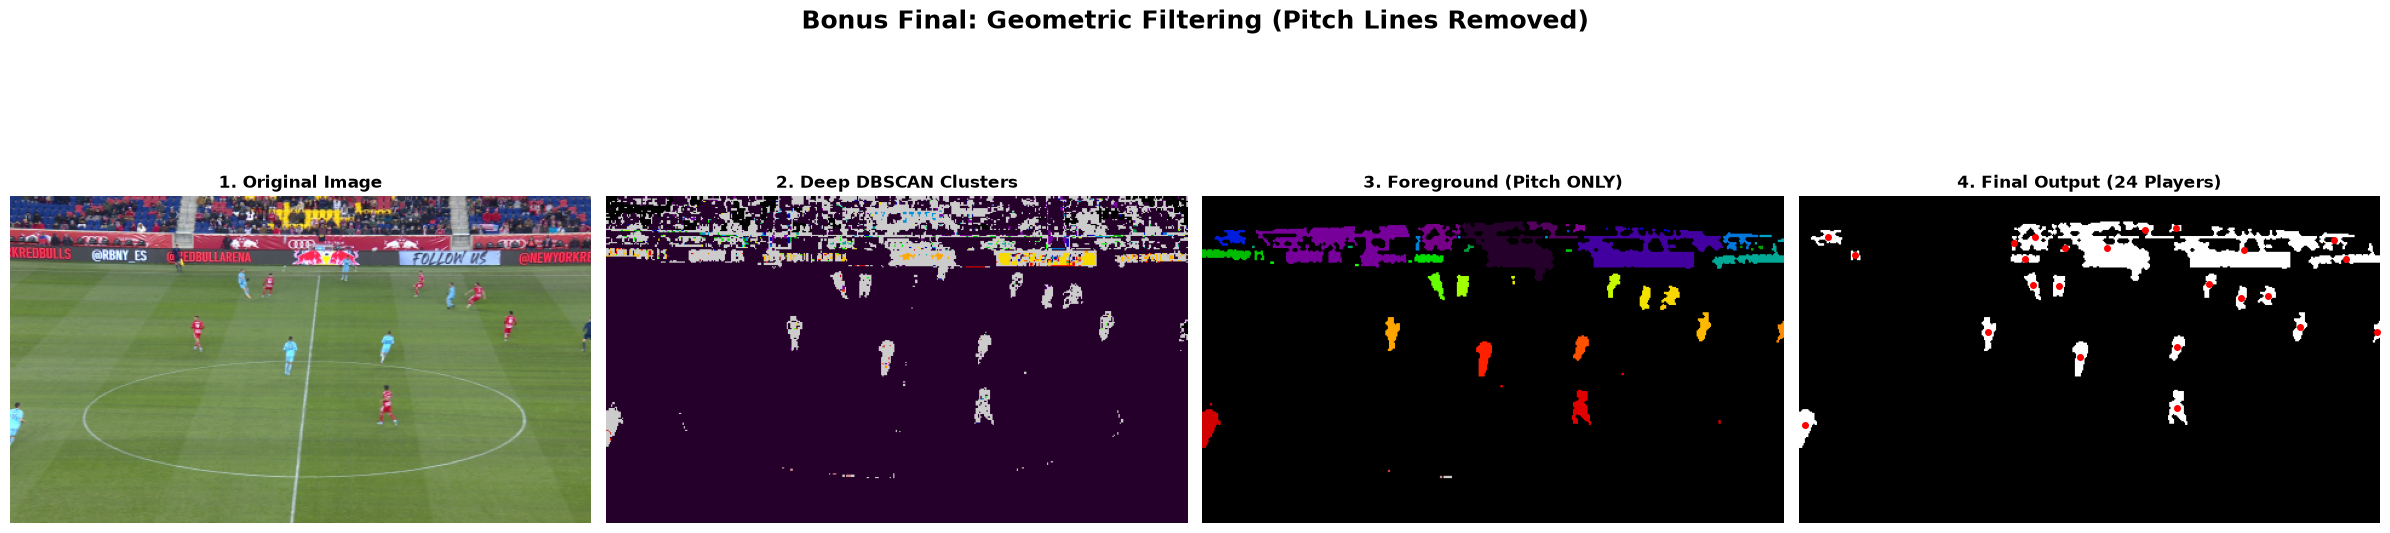

In [ ]:
# ==============================================================================
# BONUS PART6 : THE TUNED DBSCAN + PITCH ROI (CROWD & PITCH-LINES REMOVAL)
# ==============================================================================

class UltimateVisionDBSCAN:
    def __init__(self, pca_dims=3, eps=0.15, min_samples=10, rgb_weight=2.0, max_dim=384, device=None):
        self.device = device if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f" Initializing Ultimate Vision Pipeline on: {self.device}")
        
        self.model = models.resnet18(pretrained=True).to(self.device)
        self.model.eval()
        
        self.intermediate_features = {}
        def get_activation(name):
            def hook(model, input, output):
                self.intermediate_features[name] = output
            return hook
        self.model.layer1.register_forward_hook(get_activation('layer1'))
        
        self.preprocess = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        self.pca = PCA(n_components=pca_dims, random_state=42)
        self.eps = eps
        self.min_samples = min_samples
        self.rgb_weight = rgb_weight
        self.max_dim = max_dim

    def _extract_playable_area(self, cluster_map):
        print("4/5  Building Pitch ROI (Ignoring Crowd) & Extracting Foreground...")
        labels, counts = np.unique(cluster_map, return_counts=True)
        grass_label = labels[np.argmax(counts)]
        
        grass_mask = np.zeros_like(cluster_map, dtype=np.uint8)
        grass_mask[cluster_map == grass_label] = 255
        
        contours, _ = cv2.findContours(grass_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        pitch_roi = np.zeros_like(grass_mask)
        
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            hull = cv2.convexHull(largest_contour)
            cv2.fillPoly(pitch_roi, [hull], 255)
        else:
            pitch_roi[:] = 255 
            
        binary_mask = np.zeros_like(cluster_map, dtype=np.uint8)
        binary_mask[(cluster_map != grass_label) & (pitch_roi == 255)] = 255
        
        return binary_mask

    def process(self, img_rgb):
        orig_h, orig_w = img_rgb.shape[:2]
        
        scale = min(self.max_dim / orig_w, self.max_dim / orig_h)
        if scale < 1.0:
            proc_w, proc_h = int(orig_w * scale), int(orig_h * scale)
        else:
            proc_w, proc_h = orig_w, orig_h

        print(f"1/5 ⏳ Extracting Features (Safe Size: {proc_w}x{proc_h})...")
        img_tensor = self.preprocess(img_rgb).unsqueeze(0).to(self.device)
        with torch.no_grad():
            _ = self.model(img_tensor)
            
        deep_feat = self.intermediate_features['layer1']
        feat_small = F.interpolate(deep_feat, size=(proc_h, proc_w), mode='bilinear', align_corners=False)
        cnn_2d = feat_small.squeeze(0).permute(1, 2, 0).cpu().numpy()
        cnn_flat = cnn_2d.reshape((proc_h * proc_w, -1))
        
        cnn_norm = cnn_flat / (np.linalg.norm(cnn_flat, axis=1, keepdims=True) + 1e-8)
        
        print("2/5  Fusing with RGB & Applying PCA...")
        img_small = cv2.resize(img_rgb, (proc_w, proc_h), interpolation=cv2.INTER_AREA)
        rgb_flat = img_small.reshape((proc_h * proc_w, 3)).astype(np.float32) / 255.0
        
        fused = np.hstack((cnn_norm, rgb_flat * self.rgb_weight))
        pca_feats = self.pca.fit_transform(fused)
        
        final_feats = StandardScaler().fit_transform(pca_feats)
        
        print(f"3/5  Running DBSCAN (eps={self.eps}, min_samples={self.min_samples})...")
        dbscan = DBSCAN(eps=self.eps, min_samples=self.min_samples, n_jobs=-1)
        labels = dbscan.fit_predict(final_feats)
        
        if -1 in labels:
            labels[labels == -1] = np.max(labels) + 1
            
        cluster_map_small = labels.reshape((proc_h, proc_w))
        
        print("Upscaling Cluster Map to FULL HD...")
        cluster_map_full = cv2.resize(
            cluster_map_small.astype(np.float32), 
            (orig_w, orig_h), 
            interpolation=cv2.INTER_NEAREST
        ).astype(np.int32)
        
        binary_mask = self._extract_playable_area(cluster_map_full)
        
        print("5/5 ⏳ Filtering Pitch Lines & Extracting Players...")
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        opened = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)))
        closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
        
        num_labels, labels_im, stats, centroids = cv2.connectedComponentsWithStats(closed, connectivity=8)
        
        final_mask = np.zeros_like(closed, dtype=np.uint8)
        valid_centroids = []
        
        for i in range(1, num_labels):
            w_box = stats[i, cv2.CC_STAT_WIDTH]
            h_box = stats[i, cv2.CC_STAT_HEIGHT]
            area = stats[i, cv2.CC_STAT_AREA]
            
            aspect_ratio = float(w_box) / float(h_box) if h_box > 0 else 0
            bounding_box_area = w_box * h_box
            extent = float(area) / float(bounding_box_area) if bounding_box_area > 0 else 0
            
            is_valid_area = 20 <= area <= 3000
            is_valid_shape = 0.2 <= aspect_ratio <= 3.5  
            is_dense_enough = extent > 0.25
            
            if is_valid_area and is_valid_shape and is_dense_enough:
                final_mask[labels_im == i] = 255
                valid_centroids.append(centroids[i])
                
        return cluster_map_full, labels_im, final_mask, np.array(valid_centroids)

# ==============================================================================
# EXECUTION BLOCK
# ==============================================================================
if __name__ == "__main__":
    try:
        if 'test_img_norm' in locals() or 'test_img_norm' in globals():
            raw_img = test_img_norm
        elif 'test_image' in locals() or 'test_image' in globals():
            raw_img = test_image
        else:
            raise ValueError("No image found in memory!")

        img_uint8 = (raw_img[..., :3] * 255).astype(np.uint8) if raw_img.max() <= 1.0 else raw_img[..., :3].astype(np.uint8)

        pipeline = UltimateVisionDBSCAN(
            pca_dims=3,          
            eps=0.15,         
            min_samples=10,      
            rgb_weight=2.0       
        )
        
        dbscan_map, merged_parts, final_mask, centroids = pipeline.process(img_uint8)
        
        fig, axes = plt.subplots(1, 4, figsize=(24, 6))
        
        axes[0].imshow(img_uint8)
        axes[0].set_title("1. Original Image", fontweight='bold')
        axes[0].axis('off')
        
        axes[1].imshow(dbscan_map, cmap='nipy_spectral')
        axes[1].set_title("2. Deep DBSCAN Clusters", fontweight='bold')
        axes[1].axis('off')
        
        axes[2].imshow(merged_parts, cmap='nipy_spectral')
        axes[2].set_title("3. Foreground (Pitch ONLY)", fontweight='bold')
        axes[2].axis('off')
        
        axes[3].imshow(final_mask, cmap='gray')
        if len(centroids) > 0:
            axes[3].plot(centroids[:, 0], centroids[:, 1], 'ro', markersize=4)
        axes[3].set_title(f"4. Final Output ({len(centroids)} Players)", fontweight='bold')
        axes[3].axis('off')
        
        plt.suptitle("Bonus Final: Geometric Filtering (Pitch Lines Removed)", fontsize=18, fontweight='bold', y=1.05)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f" Error: {e}")

⚙️ Initializing Custom Evaluator for Part 5 Pipeline...

🚀 Streaming and evaluating 50 valid images...

1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...
1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...
1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...
1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...
1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running K-Means Clustering...
3/4 ⏳ Removing the Pitch...
4/4 ⏳ Morphological Filtering & Extracting Centroids...
1/4 ⏳ Extracting Color and Spatial Features...
2/4 ⏳ Running 

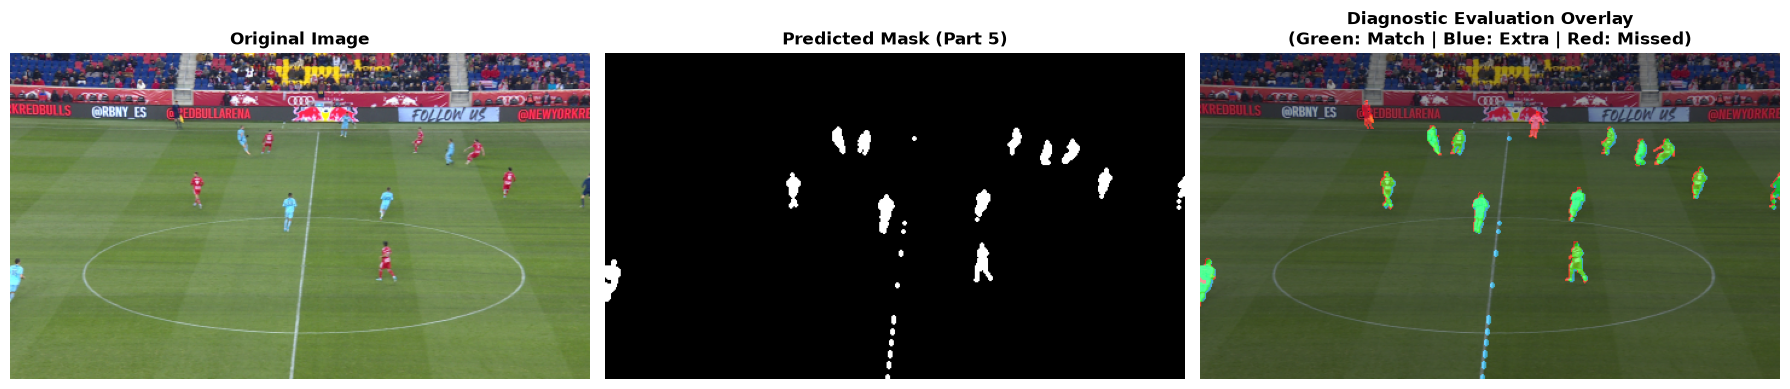

In [ ]:
# ==============================================================================
# SECTION 7: INDEPENDENT EVALUATION MODULE (PART 5 PIPELINE)
# ==============================================================================

class SegmentationEvaluator:
    """
    A memory-efficient evaluator that computes and accumulates 
    segmentation metrics (IoU, Dice) on the fly.
    """
    def __init__(self):
        self.iou_history = []
        self.dice_history = []
        self.epsilon = 1e-8 # To prevent division by zero

    def evaluate_and_record(self, prediction, ground_truth):
        # Convert inputs to strict boolean arrays
        p_mask = np.asarray(prediction, dtype=bool)
        g_mask = np.asarray(ground_truth, dtype=bool)
        
        # Core logical operations
        intersect = np.sum(p_mask & g_mask)
        union = np.sum(p_mask | g_mask)
        
        # Metric Calculations
        current_iou = intersect / (union + self.epsilon)
        current_dice = (2.0 * intersect) / (p_mask.sum() + g_mask.sum() + self.epsilon)
        
        self.iou_history.append(current_iou)
        self.dice_history.append(current_dice)

    def get_averages(self):
        return np.mean(self.dice_history), np.mean(self.iou_history)


def plot_diagnostic_overlay(image, pred_mask, gt_mask):
    """
    Creates a professional RGB diagnostic overlay:
    - GREEN : True Positives (Correctly identified players)
    - BLUE  : False Positives (Extra background/noise identified as players)
    - RED   : False Negatives (Missed players)
    """
    p = pred_mask.astype(bool)
    g = gt_mask.astype(bool)
    
    # Create an empty color canvas
    color_mask = np.zeros_like(image)
    
    color_mask[p & g] = [0, 255, 0]      # Green
    color_mask[p & ~g] = [0, 150, 255]   # Blue/Cyan
    color_mask[~p & g] = [255, 0, 0]     # Red
    
    # Blend the color mask with the original image
    blended = cv2.addWeighted(image, 0.6, color_mask, 0.6, 0)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(pred_mask, cmap='gray')
    axes[1].set_title("Predicted Mask (Part 5)", fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(blended)
    axes[2].set_title("Diagnostic Evaluation Overlay\n(Green: Match | Blue: Extra | Red: Missed)", fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# EXECUTION BLOCK (EVALUATING PART 5 DATASET)
# ==============================================================================
if __name__ == "__main__":
    try:
        if 'processed_dataset' not in locals() and 'processed_dataset' not in globals():
            raise ValueError("'processed_dataset' is missing! Run dataset loading first.")
            
        print(" Initializing Custom Evaluator for Part 5 Pipeline...\n")
        
        evaluator = SegmentationEvaluator()
        part5_pipeline = UnifiedFootballPipeline(spatial_weight=0.1, k_clusters=3)
        
        # Drop images without annotations
        valid_samples = [data for data in processed_dataset if data['gt_mask'].sum() > 0]
        total_samples = len(valid_samples)
        
        # Placeholders for visualization
        sample_img, sample_pred, sample_gt = None, None, None
        
        print(f" Streaming and evaluating {total_samples} valid images...\n")
        
        for i, data in enumerate(valid_samples):
            print(f"   ➔ Processing image {i+1}/{total_samples}...", end='\r')
            
            img = data['image']
            truth = data['gt_mask']
            
            # Predict
            _, _, predicted_mask, _ = part5_pipeline.run(img)
            
            # Record scores
            evaluator.evaluate_and_record(predicted_mask, truth)
            
            # Save the first successful extraction for the overlay plot
            if i == 0:
                sample_img = img
                sample_pred = predicted_mask
                sample_gt = truth
                
        # Retrieve final scores
        final_dice, final_iou = evaluator.get_averages()
        
        print("\n\n" + "="*50)
        print(" INDEPENDENT EVALUATION RESULTS (PART 5)")
        print("="*50)
        print(f" Average Dice Coefficient : {final_dice:.4f}")
        print(f" Average IoU Score        : {final_iou:.4f}")
        print("="*50 + "\n")

        # Visualize the diagnostic plot
        if sample_img is not None:
            plot_diagnostic_overlay(sample_img, sample_pred, sample_gt)

    except Exception as e:
        print(f"\ Runtime Error: {e}")

#  Section 8: Theoretical Questions & Analysis

### Q1: Provide an example of a segmentation task where each type of segmentation—semantic, instance, and panoptic—is appropriate and sufficient, and explain why each type suits the specific task.

**Answer:**
Image segmentation is categorized based on how it treats distinct objects and background regions (often referred to as "things" and "stuff").

1. **Semantic Segmentation:** Classifies every pixel into a predefined category but does *not* distinguish between different objects of the same class.
   * **Example Task:** **Drivable Area Detection in Autonomous Driving.** * **Why it suits:** For navigation, the car only needs to know which pixels constitute the "road" versus "sidewalk" or "sky". It does not matter if the road is made of one continuous lane or multiple connected segments; identifying the sheer boundaries of the semantic class is entirely sufficient for path planning.

2. **Instance Segmentation:** Identifies and separates individual countable objects ("things") at the pixel level but ignores the background ("stuff").
   * **Example Task:** **Cell Counting and Tracking in Medical Imaging (e.g., identifying individual red blood cells).**
   * **Why it suits:** It is crucial to know *how many* cells exist, their individual sizes, and their distinct boundaries to detect abnormalities. Semantic segmentation would merge overlapping cells into one massive blob, making counting impossible, whereas instance segmentation treats each cell as an independent entity (Cell 1, Cell 2, etc.).

3. **Panoptic Segmentation:** The unification of both. It assigns a semantic label to every pixel (stuff) *and* uniquely identifies distinct instances of countable objects (things).
   * **Example Task:** **Advanced Urban Scene Understanding.**
   * **Why it suits:** An autonomous vehicle in a complex city needs to know the exact boundaries of the continuous road/sky (Semantic) while simultaneously tracking exactly *how many* distinct pedestrians or cars are in front of it (Instance). Panoptic segmentation provides this holistic, 100% pixel-dense understanding of the scene.

---

### Q2: Explain the difference between the Dice coefficient and Intersection over Union (IoU) as evaluation metrics in image segmentation. In what scenarios might one be preferred over the other?

**Answer:**
Both metrics measure the spatial overlap between the Predicted Mask ($P$) and the Ground Truth Mask ($G$), but they behave differently mathematically.

**1. Mathematical Definitions:**
* **Intersection over Union (IoU / Jaccard Index):** Calculates the area of overlap divided by the area of union.
  $$\text{IoU} = \frac{|P \cap G|}{|P \cup G|} = \frac{TP}{TP + FP + FN}$$
* **Dice Coefficient (F1-Score):** Calculates twice the area of overlap divided by the total number of pixels in both masks.
  $$\text{Dice} = \frac{2 |P \cap G|}{|P| + |G|} = \frac{2TP}{2TP + FP + FN}$$

**2. Core Differences & Scenarios for Preference:**
* **Metric Strictness:** The two metrics are related by $\text{Dice} = \frac{2 \times \text{IoU}}{1 + \text{IoU}}$. Because of this, IoU is mathematically more stringent. It penalizes false positives and false negatives much more severely. 
  * *Preference:* **IoU** is preferred in standard object detection and benchmarks (like PASCAL VOC or COCO) where you want to strictly evaluate boundary precision and penalize sloppy segmentations.
* **Class Imbalance & Loss Formulation:** * *Preference:* The **Dice Coefficient** is heavily preferred in **Medical Imaging** and highly imbalanced datasets (e.g., segmenting a tiny tumor in a large MRI scan). It represents the harmonic mean of precision and recall (F1-score), making it more robust to background dominance. Furthermore, continuous versions of the Dice metric provide smoother gradients when used as a Loss Function during the training of Deep Neural Networks (e.g., U-Net).

---

### Q3: How can autoencoders be used to reduce the dimensionality of images before clustering, and how does this improve K-means efficiency and effectiveness on large datasets?

**Answer:**
Directly applying distance-based clustering algorithms like K-Means to raw high-dimensional image data (e.g., thousands of pixels) leads to two massive problems: **The Curse of Dimensionality** (where Euclidean distances lose meaning) and severe **computational inefficiency** $\mathcal{O}(N \times K \times D)$.

**1. How Autoencoders are Used:**
An Autoencoder is an unsupervised neural network consisting of two parts:
* **The Encoder ($f_\theta$):** Compresses the high-dimensional input image $x \in \mathbb{R}^D$ into a low-dimensional dense latent representation (bottleneck) $z \in \mathbb{R}^d$, where $d \ll D$.
  $$z = f_\theta(x)$$
* **The Decoder ($g_\phi$):** Attempts to reconstruct the original image from the latent space $\hat{x} = g_\phi(z)$. The network is trained by minimizing the Reconstruction Loss: $\mathcal{L} = ||x - \hat{x}||^2$.
Once trained, we discard the decoder and pass our large image dataset strictly through the Encoder. We then apply K-Means to the low-dimensional vectors $z$.

**2. Improving Efficiency and Effectiveness:**
* **Efficiency (Speed & Memory):** By reducing the feature dimension from $D$ (e.g., $256 \times 256 = 65,536$) to a compact $d$ (e.g., $128$), the distance computations in K-means drop drastically. The algorithm converges exponentially faster and requires vastly less RAM, allowing it to process massive datasets seamlessly.
* **Effectiveness (Clustering Quality):** Raw pixels contain immense noise, varying illumination, and irrelevant background details. The Autoencoder's bottleneck forces the network to learn invariant, **high-level semantic features** (shapes, textures, patterns). Consequently, in the latent space $z$, images with similar semantic content are mapped closer together, making the Euclidean distance metric of K-Means highly effective and resulting in pure, meaningful clusters.